In [6]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print(df.head())
print(df.info())
print(df.shape)


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [7]:
print("Missing values:\n")
print(df.isnull().sum())



Missing values:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
df = df.drop_duplicates()
print("\nDuplicates removed ✅")



Duplicates removed ✅


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])


In [10]:
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month


In [11]:
print(df[["Order Date","Order_Year","Order_Month"]].head())


  Order Date  Order_Year  Order_Month
0 2016-11-08        2016           11
1 2016-11-08        2016           11
2 2016-06-12        2016            6
3 2015-10-11        2015           10
4 2015-10-11        2015           10


In [12]:
total_sales = df["Sales"].sum()
print("TOTAL SALES =", round(total_sales,2))


TOTAL SALES = 2297200.86


In [13]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("\nREGION WISE SALES:\n", region_sales)



REGION WISE SALES:
 Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [14]:
top_products = df.groupby("Product Name")["Profit"] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head()

print("\nTOP 5 PRODUCTS:\n", top_products)



TOP 5 PRODUCTS:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Name: Profit, dtype: float64


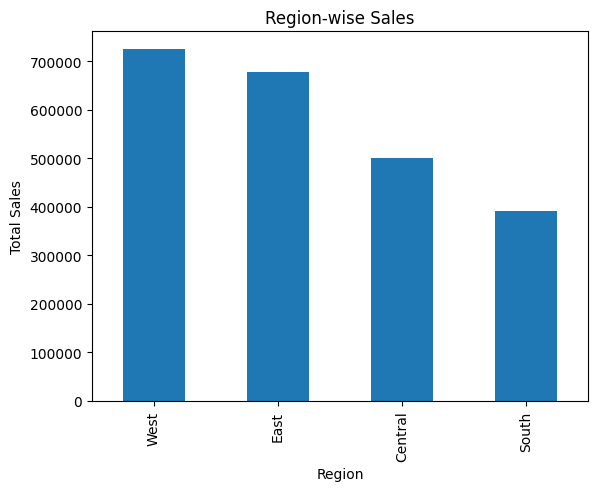

In [15]:
import matplotlib.pyplot as plt

region_sales.plot(kind="bar")
plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


In [19]:
print("Best Region = West")
print("Top Profit Product = Canon imageCLASS 2200 Advanced Copier")
print("Total Sales = 2297200.86")


Best Region = West
Top Profit Product = Canon imageCLASS 2200 Advanced Copier
Total Sales = 2297200.86
